# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [56]:
from google.colab import files
uploaded = files.upload()

Saving MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv to MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv (2).csv


In [57]:
df = pd.read_csv('MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv', delimiter=',')
# Remove any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

df.head(10)
print('Columns after processing:', df.columns)

Columns after processing: Index(['title', 'Marca', 'Preco_Normal', 'Preco_Desconto', 'Preco_Anterior',
       'Desconto', 'Categoria'],
      dtype='object')


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identificação das categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [58]:
# Calcula a média
df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values(by='Preco_Normal', ascending=False)

,Categoria,Preco_Normal
1,comidas-preparadas,3095.043478
5,lacteos,2385.219239
2,congelados,2108.042553
0,belleza-y-cuidado-personal,1783.556485
3,frutas,1724.473684
6,verduras,1343.296875
4,instantaneos-y-sopas,765.491228


In [59]:
# Calcula a mediana
df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values(by='Preco_Normal', ascending=False)

,Categoria,Preco_Normal
1,comidas-preparadas,3290.0
0,belleza-y-cuidado-personal,1569.0
2,congelados,1519.0
3,frutas,1195.0
6,verduras,1180.0
5,lacteos,989.0
4,instantaneos-y-sopas,439.0



As categorias frutas, verduras e instantaneos-y-sopas possuem um valor abaixo da média

# 2 - Desvio padrão por categoria de produto.


In [60]:
# Traz o desvio padrão por categoria
desvio_padrao_por_categoria = df.groupby('Categoria')['Preco_Normal'].std().reset_index()

# Junta tudo em uma única tabela
estatisticas = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median', 'std']).reset_index()

# Ordena pelas categorias com maior desvio
estatisticas = estatisticas.sort_values(by='std', ascending=False)

# Mostra o resultado
estatisticas.head()

,Categoria,mean,median,std
5,lacteos,2385.219239,989.0,3925.816164
0,belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719
2,congelados,2108.042553,1519.0,2111.539896
1,comidas-preparadas,3095.043478,3290.0,2019.911428
3,frutas,1724.473684,1195.0,1639.151114


As categorias com maior desvio padrão apresentam maior variação nos preços dos produtos. Em especial, a categoria de lácteos apresenta o maior desvio, indicando preços muito altos.

# 3 - Boxplot da distribuição do Preco_Normal para a categoria que tem o maior desvio padrão.

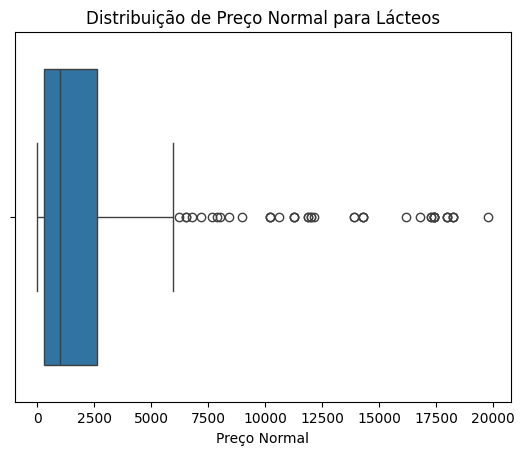

In [61]:
# Mantém apenas as linhas da categoria "lacteos"
df_lacteos = df[df['Categoria'] == 'lacteos']


# Gráfico boxplot
sns.boxplot(x=df_lacteos['Preco_Normal'])
plt.xlabel('Preço Normal')
plt.title('Distribuição de Preço Normal para Lácteos')
plt.show()

A maior parte dos dados está concentrada nos valores mais baixos, mas existem alguns produtos mais caros (outliers), como mostra a parte direita do gráfico.

# 4 - Gráfico de barras onde temos a média de descontos por categoria.



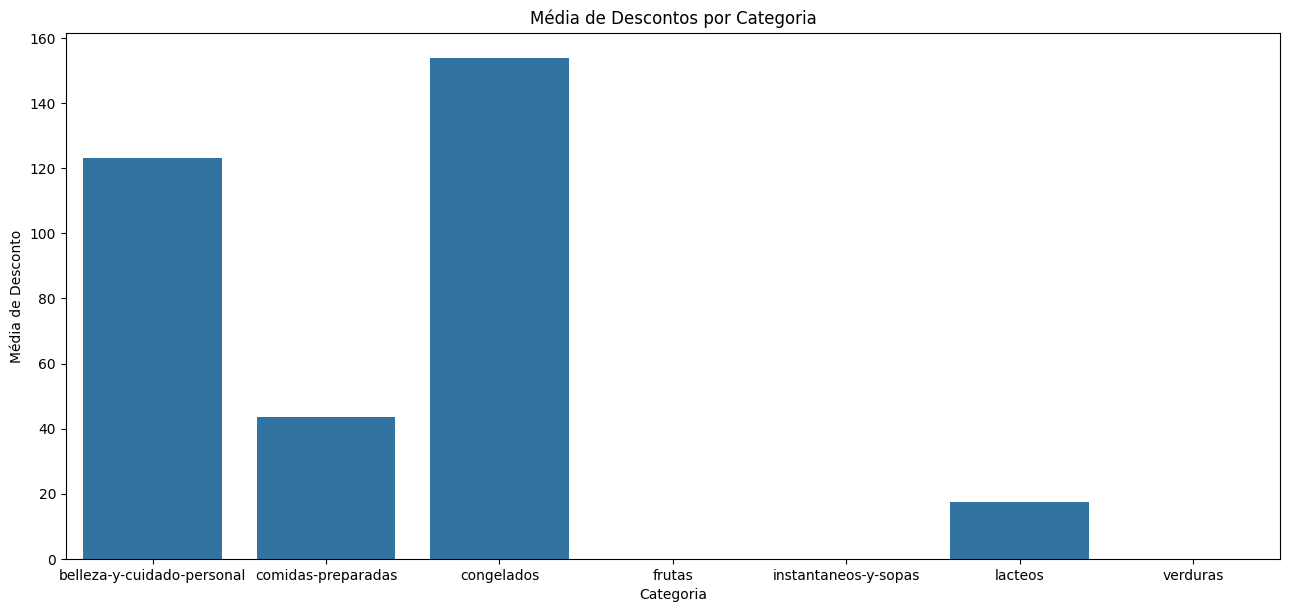

In [62]:
# Agrupa os dados por categoria e calcula a média dos descontos em cada uma
media_descontos = df.groupby('Categoria')['Desconto'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(13,6))
sns.barplot(data=media_descontos, x='Categoria', y='Desconto')
plt.tight_layout()
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')
plt.title('Média de Descontos por Categoria')
plt.show()


# 5 - Gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [65]:
# Agrupa os dados por "Categoria" e "Marca", calculando a média dos descontos
media_desc = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

# Gráfico interativo
fig = px.bar(
    media_desc,
    x='Categoria',
    y='Desconto',
    color='Marca',
    title='Média de Desconto por Categoria e Marca'
)

df.head()

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos


In [66]:
fig.show()